In [ ]:
# importer les ibliothèques nécessaires pour le projet
import cv2              
import numpy as np     
import os              
from pathlib import Path  
import json             
from datetime import datetime  
import matplotlib.pyplot as plt 
from IPython.display import Image, display  


In [ ]:
class FaceBlurProcessor:
    """
    Classe principale pour la détection et le floutage automatique des visages.
    Utilise les classificateurs Haar Cascade d'OpenCV pour détecter les visages
    et applique un flou gaussien ou une pixelisation pour anonymiser.
    """
    
class FaceBlurProcessor:
    """
    Classe principale pour la détection et le floutage automatique des visages.
    Utilise les classificateurs Haar Cascade d'OpenCV pour détecter les visages
    et applique un flou gaussien ou une pixelisation pour anonymiser.
    """
    
    def __init__(self, images_dir="images", output_dir="output", blur_method="gaussian"):
        """Initialise le processeur de floutage de visages"""
        # Stocker les chemins des répertoires
        self.images_dir = Path(images_dir)
        self.output_dir = Path(output_dir)
        self.blur_method = blur_method
        
        # Créer les répertoires de sortie s'ils n'existent pas
        self.output_dir.mkdir(exist_ok=True)
        (self.output_dir / "blurred").mkdir(exist_ok=True)
        (self.output_dir / "comparison").mkdir(exist_ok=True)
        
        # Charger le classificateur Haar cascade pour les visages frontaux
        frontal_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        if not os.path.exists(frontal_cascade_path):
            raise FileNotFoundError(f"Fichier Haar cascade non trouvé: {frontal_cascade_path}")
        
        self.face_cascade = cv2.CascadeClassifier(frontal_cascade_path)
        
        # Charger le classificateur pour les visages de profil 
        profile_cascade_path = cv2.data.haarcascades + 'haarcascade_profileface.xml'
        if os.path.exists(profile_cascade_path):
            self.profile_cascade = cv2.CascadeClassifier(profile_cascade_path)
        else:
            self.profile_cascade = None
        
        # Dictionnaire pour stocker les statistiques du traitement
        self.stats = {
            "total_images": 0,
            "images_with_faces": 0,
            "total_faces_detected": 0,
            "false_positives": 0,
            "false_negatives": 0,
            "processing_time": 0
        }
    
    def detect_faces(self, image):
        """Détecte les visages dans une image en utilisant plusieurs méthodes"""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        all_faces = []
        
        # Détection frontale - configuration 1
        faces_frontal1 = self.face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40), 
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        if len(faces_frontal1) > 0:
            all_faces.extend(faces_frontal1)
        
        # Détection frontale - configuration 2
        faces_frontal2 = self.face_cascade.detectMultiScale(
            gray, scaleFactor=1.15, minNeighbors=6, minSize=(50, 50), 
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        if len(faces_frontal2) > 0:
            all_faces.extend(faces_frontal2)
        
        # Détection de profil
        if self.profile_cascade is not None:
            faces_profile1 = self.profile_cascade.detectMultiScale(
                gray, scaleFactor=1.15, minNeighbors=6, minSize=(45, 45), 
                flags=cv2.CASCADE_SCALE_IMAGE
            )
            if len(faces_profile1) > 0:
                all_faces.extend(faces_profile1)
            
            gray_flipped = cv2.flip(gray, 1)
            faces_profile_flipped1 = self.profile_cascade.detectMultiScale(
                gray_flipped, scaleFactor=1.15, minNeighbors=6, minSize=(45, 45), 
                flags=cv2.CASCADE_SCALE_IMAGE
            )
            if len(faces_profile_flipped1) > 0:
                h, w = gray.shape
                for (x, y, w_face, h_face) in faces_profile_flipped1:
                    x_corrected = w - x - w_face
                    all_faces.append([x_corrected, y, w_face, h_face])
        
        # Amélioration du contraste avec CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        gray_enhanced = clahe.apply(gray)
        
        faces_enhanced = self.face_cascade.detectMultiScale(
            gray_enhanced, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40), 
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        if len(faces_enhanced) > 0: 
            all_faces.extend(faces_enhanced)
            
            if self.profile_cascade is not None:
                faces_profile_enhanced1 = self.profile_cascade.detectMultiScale(
                    gray_enhanced, scaleFactor=1.15, minNeighbors=6, minSize=(45, 45), 
                    flags=cv2.CASCADE_SCALE_IMAGE
                )
                if len(faces_profile_enhanced1) > 0:
                    all_faces.extend(faces_profile_enhanced1)
                
                gray_enhanced_flipped = cv2.flip(gray_enhanced, 1)
                faces_profile_enhanced_flipped1 = self.profile_cascade.detectMultiScale(
                    gray_enhanced_flipped, scaleFactor=1.15, minNeighbors=6, minSize=(45, 45), 
                    flags=cv2.CASCADE_SCALE_IMAGE
                )
                if len(faces_profile_enhanced_flipped1) > 0:
                    h, w = gray_enhanced.shape
                    for (x, y, w_face, h_face) in faces_profile_enhanced_flipped1:
                        x_corrected = w - x - w_face
                        all_faces.append([x_corrected, y, w_face, h_face])
        
        # Validation et filtrage des faux positifs
        if len(all_faces) > 0:
            all_faces = np.array(all_faces)
            validated_faces = []
            h_img, w_img = gray.shape
            
            for (x, y, w, h) in all_faces:
                if x < 0 or y < 0 or x + w > w_img or y + h > h_img:
                    continue
                
                aspect_ratio = w / h if h > 0 else 0
                if aspect_ratio < 0.65 or aspect_ratio > 1.4:
                    continue
                
                if w < 35 or h < 35:
                    continue
                
                if w > w_img / 3 or h > h_img / 3:
                    continue
                
                perimeter = 2 * (w + h)
                area = w * h
                if perimeter > 0:
                    compactness = 4 * np.pi * area / (perimeter * perimeter)
                    if compactness < 0.4:
                        continue
                
                validated_faces.append([x, y, w, h])
            
            if len(validated_faces) > 0:
                validated_faces = np.array(validated_faces)
                faces_merged = self._merge_overlapping_faces(validated_faces)
                return faces_merged
        
        return []
    
    def _merge_overlapping_faces(self, faces):
        """Fusionne les rectangles de visages qui se chevauchent"""
        if len(faces) == 0:
            return []
        
        faces = faces[faces[:, 2].argsort()[::-1]]
        merged = []
        used = [False] * len(faces)
        
        for i, (x1, y1, w1, h1) in enumerate(faces):
            if used[i]:
                continue
            current = [x1, y1, w1, h1]
            
            for j, (x2, y2, w2, h2) in enumerate(faces[i+1:], i+1):
                if used[j]:
                    continue
                
                overlap_x = max(0, min(x1 + w1, x2 + w2) - max(x1, x2))
                overlap_y = max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
                overlap_area = overlap_x * overlap_y
                
                area1, area2 = w1 * h1, w2 * h2
                union_area = area1 + area2 - overlap_area
                
                if union_area > 0 and overlap_area / union_area > 0.6:
                    x_min, y_min = min(x1, x2), min(y1, y2)
                    x_max, y_max = max(x1 + w1, x2 + w2), max(y1 + h1, y2 + h2)
                    current = [x_min, y_min, x_max - x_min, y_max - y_min]
                    used[j] = True
            
            merged.append(current)
            used[i] = True
        
        return np.array(merged, dtype=np.int32)
    
    def apply_gaussian_blur(self, image, face_region, blur_strength=None):
        """Applique un flou gaussien à une région de visage"""
        x, y, w, h = face_region
        result = image.copy()
        
        padding = 10
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(result.shape[1] - x, w + 2 * padding)
        h = min(result.shape[0] - y, h + 2 * padding)
        
        if blur_strength is None:
            blur_strength = max(51, min(w, h) // 4)
            if blur_strength % 2 == 0:
                blur_strength += 1
        else:
            if blur_strength % 2 == 0:
                blur_strength += 1
        
        face_roi = result[y:y+h, x:x+w]
        blurred_face = cv2.GaussianBlur(face_roi, (blur_strength, blur_strength), 0)
        blurred_face = cv2.GaussianBlur(blurred_face, (blur_strength, blur_strength), 0)
        result[y:y+h, x:x+w] = blurred_face
        return result
    
    def apply_pixelation(self, image, face_region, pixel_size=None):
        """Applique une pixelisation à une région de visage"""
        x, y, w, h = face_region
        result = image.copy()
        
        padding = 10
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(result.shape[1] - x, w + 2 * padding)
        h = min(result.shape[0] - y, h + 2 * padding)
        
        if pixel_size is None:
            pixel_size = max(20, min(w, h) // 8)
        
        face_roi = result[y:y+h, x:x+w]
        small = cv2.resize(face_roi, 
                          (max(1, w // pixel_size), max(1, h // pixel_size)), 
                          interpolation=cv2.INTER_LINEAR)
        pixelated = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
        result[y:y+h, x:x+w] = pixelated
        return result
    
    def blur_faces(self, image, faces):
        """Applique le floutage à tous les visages détectés"""
        result = image.copy()
        for (x, y, w, h) in faces:
            if self.blur_method == "gaussian":
                result = self.apply_gaussian_blur(result, (x, y, w, h))
            elif self.blur_method == "pixelate":
                result = self.apply_pixelation(result, (x, y, w, h))
        return result
    
    def create_comparison(self, original, blurred, faces):
        """Crée une image de comparaison côte à côte"""
        original_with_boxes = original.copy()
        for (x, y, w, h) in faces:
            cv2.rectangle(original_with_boxes, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
        h, w = original.shape[:2]
        max_height = 800
        if h > max_height:
            scale = max_height / h
            new_w, new_h = int(w * scale), int(h * scale)
            original_with_boxes = cv2.resize(original_with_boxes, (new_w, new_h))
            blurred_resized = cv2.resize(blurred, (new_w, new_h))
        else:
            blurred_resized = blurred
        
        comparison = np.hstack([original_with_boxes, blurred_resized])
        cv2.putText(comparison, "AVANT (visages detectes)", (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.putText(comparison, "APRES (visages floutes)", (w + 10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        return comparison
    
    def process_image(self, image_path):
        """Traite une image complète : détecte et floute les visages"""
        image = cv2.imread(str(image_path))
        if image is None:
            print(f"Erreur: Impossible de charger l'image {image_path}")
            return None, None, None
        
        faces = self.detect_faces(image)
        
        if len(faces) > 0:
            blurred_image = self.blur_faces(image, faces)
            comparison = self.create_comparison(image, blurred_image, faces)
        else:
            blurred_image = image.copy()
            comparison = self.create_comparison(image, image, [])
        
        return len(faces), blurred_image, comparison
    
    def process_all_images(self):
        """Traite toutes les images du répertoire"""
        image_extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
        image_files = [f for f in self.images_dir.iterdir() 
                      if f.suffix in image_extensions]
        
        self.stats["total_images"] = len(image_files)
        
        print(f"Début du traitement de {len(image_files)} images...")
        print(f"Méthode de floutage: {self.blur_method}\n")
        
        start_time = datetime.now()
        
        for idx, image_path in enumerate(image_files, 1):
            print(f"[{idx}/{len(image_files)}] Traitement de {image_path.name}...", end=" ")
            
            num_faces, blurred, comparison = self.process_image(image_path)
            
            if blurred is not None:
                output_path = self.output_dir / "blurred" / f"blurred_{image_path.name}"
                cv2.imwrite(str(output_path), blurred)
                
                comparison_path = self.output_dir / "comparison" / f"comparison_{image_path.name}"
                cv2.imwrite(str(comparison_path), comparison)
                
                if num_faces > 0:
                    self.stats["images_with_faces"] += 1
                    self.stats["total_faces_detected"] += num_faces
                    print(f"[OK] {num_faces} visage(s) detecte(s) et floute(s)")
                else:
                    print("[OK] Aucun visage detecte")
            else:
                print("[ERREUR] Erreur lors du traitement")
        
        end_time = datetime.now()
        self.stats["processing_time"] = (end_time - start_time).total_seconds()
        
        print(f"\n{'='*60}")
        print("Traitement terminé !")
        print(f"{'='*60}")
    
    def save_statistics(self):
        """Sauvegarde les statistiques du traitement"""
        stats_file = self.output_dir / "statistics.json"
        
        with open(stats_file, 'w', encoding='utf-8') as f:
            json.dump(self.stats, f, indent=2, ensure_ascii=False)
        
        print(f"\nStatistiques sauvegardées dans {stats_file}")
        print("\nRésumé des statistiques:")
        print(f"  - Images totales: {self.stats['total_images']}")
        print(f"  - Images avec visages: {self.stats['images_with_faces']}")
        print(f"  - Total visages détectés: {self.stats['total_faces_detected']}")
        print(f"  - Temps de traitement: {self.stats['processing_time']:.2f} secondes")
        if self.stats['total_images'] > 0:
            print(f"  - Temps moyen par image: {self.stats['processing_time']/self.stats['total_images']:.2f} secondes")


In [ ]:
# EXÉCUTION DU TRAITEMENT

# Créer une instance du processeur
# images_dir : dossier contenant les images à traiter
# output_dir : dossier où sauvegarder les résultats
# blur_method : "gaussian" pour flou gaussien ou "pixelate" pour pixelisation
processor = FaceBlurProcessor(
    images_dir="images",
    output_dir="output",
    blur_method="gaussian"  # Changer en "pixelate" pour utiliser la pixelisation
)

# Traiter toutes les images du dossier "images"
processor.process_all_images()

# Sauvegarder les statistiques dans output/statistics.json
processor.save_statistics()


Début du traitement de 35 images...
Méthode de floutage: gaussian

[1/35] Traitement de 0e526af3540c9df229321de684dd5f42.jpg... [OK] 4 visage(s) detecte(s) et floute(s)
[2/35] Traitement de 2722d275dfd6f57d4157ea0fa0548fc6.jpg... [OK] 3 visage(s) detecte(s) et floute(s)
[3/35] Traitement de 2aa7d4d37155d50f852a357717db31ba.jpg... [OK] 3 visage(s) detecte(s) et floute(s)
[4/35] Traitement de 67028dca81ec5adece5ed74f3748139d.jpg... [OK] 4 visage(s) detecte(s) et floute(s)
[5/35] Traitement de a6816969cc37927a5232646a776fd63a.jpg... [OK] 1 visage(s) detecte(s) et floute(s)
[6/35] Traitement de annie-spratt-C5HVTcjILHk-unsplash.jpg... [OK] 35 visage(s) detecte(s) et floute(s)
[7/35] Traitement de asael-pena-iJhmN8NfVjE-unsplash.jpg... [OK] 23 visage(s) detecte(s) et floute(s)
[8/35] Traitement de atsadawut-chaiseeha-ptJ36tBQDOo-unsplash.jpg... [OK] 35 visage(s) detecte(s) et floute(s)
[9/35] Traitement de ca2295cbbebf55d0a24d0d84509a5203.jpg... [OK] 5 visage(s) detecte(s) et floute(s)
[10/

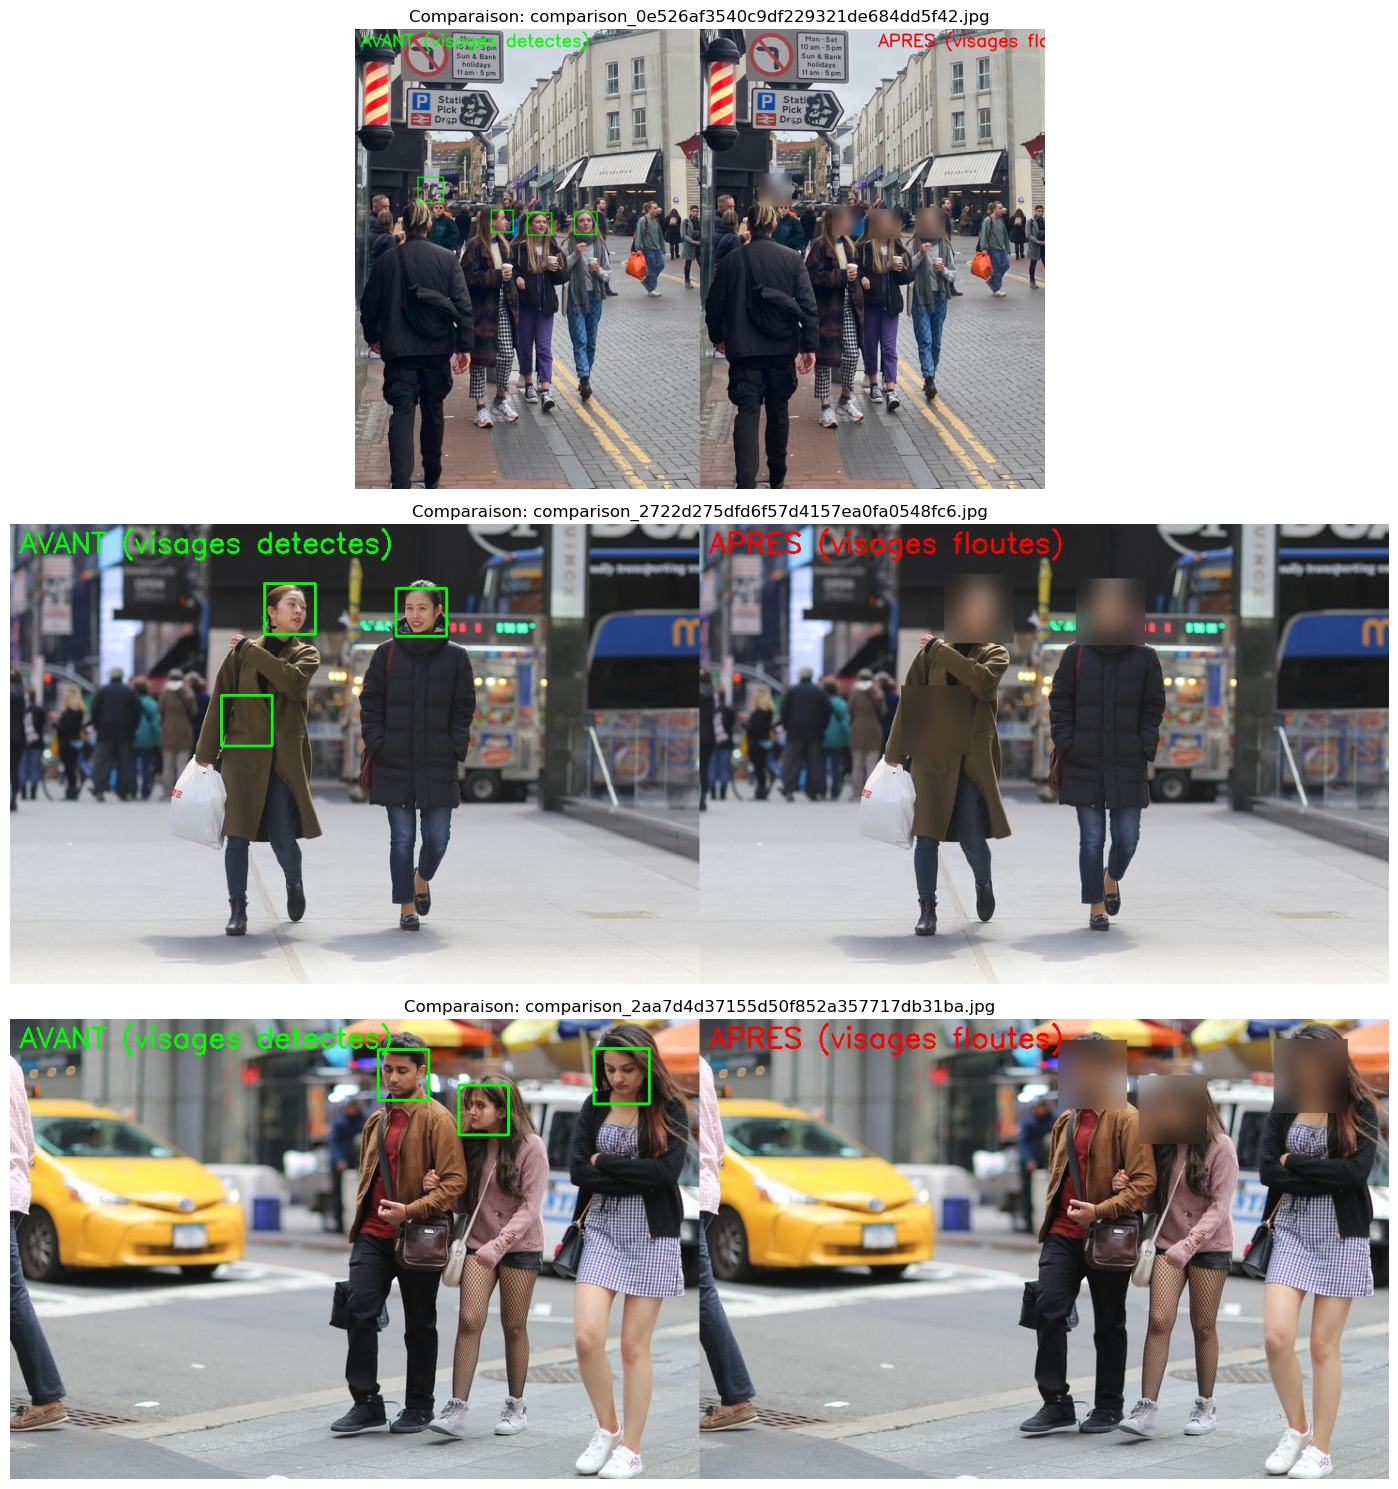

In [ ]:
# Afficher quelques exemples de comparaisons
comparison_dir = Path("output/comparison")
comparison_files = list(comparison_dir.glob("*.jpg"))[:3]  # Afficher les 3 premières

if len(comparison_files) > 0:
    fig, axes = plt.subplots(len(comparison_files), 1, figsize=(15, 5*len(comparison_files)))
    
    if len(comparison_files) == 1:
        axes = [axes]
    
    for idx, comp_path in enumerate(comparison_files):
        img = cv2.imread(str(comp_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img_rgb)
        axes[idx].axis('off')
        axes[idx].set_title(f"Comparaison: {comp_path.name}", fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image de comparaison trouvée. Exécutez d'abord la cellule précédente.")


In [ ]:
# Charger et afficher les statistiques
stats_file = Path("output/statistics.json")
if stats_file.exists():
    with open(stats_file, "r", encoding="utf-8") as f:
        stats = json.load(f)
    
    print("="*60)
    print("STATISTIQUES DU TRAITEMENT")
    print("="*60)
    print(f"Images totales: {stats['total_images']}")
    print(f"Images avec visages: {stats['images_with_faces']}")
    print(f"Total visages détectés: {stats['total_faces_detected']}")
    print(f"Temps de traitement: {stats['processing_time']:.2f} secondes")
    if stats['total_images'] > 0:
        print(f"Temps moyen par image: {stats['processing_time']/stats['total_images']:.2f} secondes")
    print("="*60)
else:
    print("Fichier de statistiques non trouvé. Exécutez d'abord le traitement.")


STATISTIQUES DU TRAITEMENT
Images totales: 35
Images avec visages: 35
Total visages détectés: 931
Temps de traitement: 449.68 secondes
Temps moyen par image: 12.85 secondes


Traitement de l'image: 0e526af3540c9df229321de684dd5f42.jpg


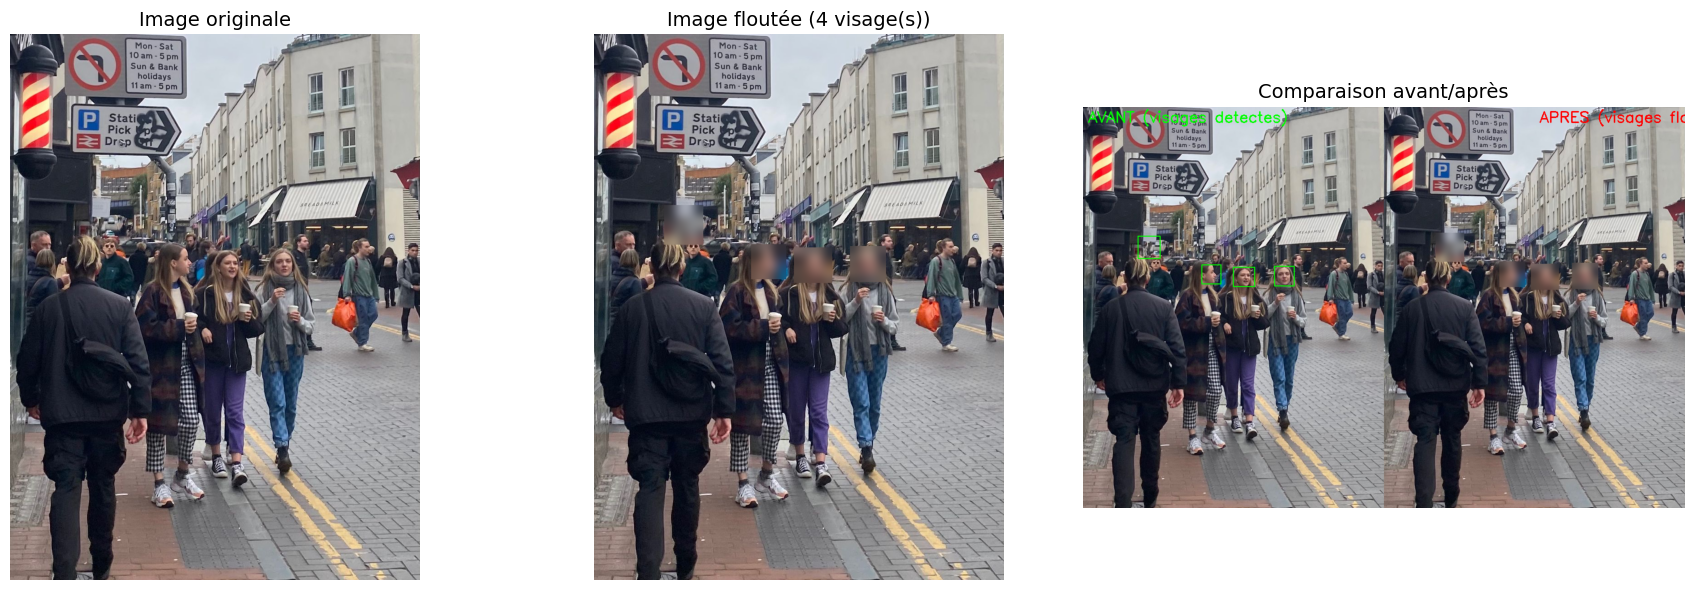

In [ ]:
# Exemple : traiter une seule image
image_files = list(Path("images").glob("*.jpg"))
if len(image_files) > 0:
    example_image = image_files[0]
    print(f"Traitement de l'image: {example_image.name}")
    
    num_faces, blurred, comparison = processor.process_image(example_image)
    
    # Afficher les résultats
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Image originale
    original = cv2.imread(str(example_image))
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    axes[0].imshow(original_rgb)
    axes[0].set_title("Image originale", fontsize=14)
    axes[0].axis('off')
    
    # Image floutée
    blurred_rgb = cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB)
    axes[1].imshow(blurred_rgb)
    axes[1].set_title(f"Image floutée ({num_faces} visage(s))", fontsize=14)
    axes[1].axis('off')
    
    # Comparaison
    comparison_rgb = cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB)
    axes[2].imshow(comparison_rgb)
    axes[2].set_title("Comparaison avant/après", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Aucune image trouvée dans le dossier images/")
